## Python For Machine Learning Fall 2025
---
# ML Miscellaneous

Welcome to this comprehensive notebook covering essential techniques in modern Deep Learning using PyTorch. While often categorized as "miscellaneous," these concepts—loss functions, normalization, regularization, optimizers, and data augmentation—are the building blocks of state-of-the-art models.

# 1. Softmax and Cross Entropy Loss

In multi-class classification problems, we often need our model to output a probability distribution over $C$ classes.


## 1.1 Formula


**Softmax Function**:
Given a vector of raw scores (logits) $z$, the Softmax function $\sigma(z)_i$ for the $i$-th class is defined as:
$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^C e^{z_j}}$$



**Cross Entropy Loss**:
To train the model, we penalize the difference between the predicted probability distribution and the true distribution. n information theory, the Cross Entropy between a **true distribution ($y$)** and a **predicted distribution ($\hat{y}$)** is defined as:

$$Loss = - \sum_{i=1}^{C} y_i \cdot \log(\hat{y}_i)$$

**Where:**
- $C$: Total number of classes.
- $y_i$: Probability of the true label for class $i$.
- $\hat{y}_i$: Probability predicted by the model (Softmax output) for class $i$.



In standard classification, we use **One-Hot Encoding**. If we have 3 classes (Cat, Dog, Bird) and the image is a **Dog** (Index 1), our ground truth vector $y$ is:

$$y = [0, 1, 0]$$

This means:
- $y_0 (\text{Cat}) = 0$
- $y_1 (\text{Dog}) = 1$ (The Target)
- $y_2 (\text{Bird}) = 0$

Substitute the One-Hot vector `[0, 1, 0]` into the general summation formula:
$$Loss = - [ (y_0 \cdot \log(\hat{y}_0)) + (y_1 \cdot \log(\hat{y}_1)) + (y_2 \cdot \log(\hat{y}_2)) ]$$

$$Loss = - [ (0 \cdot \log(\hat{y}_0)) + (1 \cdot \log(\hat{y}_1)) + (0 \cdot \log(\hat{y}_2)) ]$$

Since $0$ multiplied by anything is $0$, the terms for Cat and Bird vanish completely.

$$Loss = - [ 0 + 1 \cdot \log(\hat{y}_1) + 0 ]$$

$$Loss = - \log(\hat{y}_1)$$



Due to the zeros in the One-Hot vector, the summation collapses to a single term regarding the target class only:

$$Loss = - \log(\hat{y}_{\text{target}})$$

We only need to calculate the negative log probability of the **correct label**. This is why implementation functions (like `NLLLoss`) only require an index lookup (selecting the target value) rather than a complex matrix multiplication.


## 1.2 Numerical Stability

Performing Softmax and Log calculations separately creates numerical issues. The fused LogSoftmax method effectively resolves this.

### 1.2.1 Overflow

The standard Softmax formula requires calculating exponentials: $e^{z_i}$.
If your network is untrained or weights are initialized poorly, a logit value ($z$) could be large, for example, **1000**. Mathematically, $e^{1000}$ is a valid, gigantic number. However, in computer memory (specifically standard `float32` precision):

$$e^{1000} \approx \infty \text{ (Infinity)}$$

The computer cannot represent this number. It results in an **Overflow**, causing the code to crash or produce `NaN` (Not a Number) values, ruining the training.

### The LogSoftmax Solution (The "Max-Shift" Trick)
`LogSoftmax` uses a mathematical trick. It identifies the maximum value in the logits (let's call it $M$) and subtracts it from all logits before calculating the exponential.

$$\frac{e^{z_i - M}}{\sum e^{z_j - M}} = \frac{e^{z_i} / e^M}{(\sum e^{z_j}) / e^M} = \frac{e^{z_i}}{\sum e^{z_j}}$$

Mathematically, the result is identical. However, numerically, the largest exponent becomes $e^{M-M} = e^0 = 1$. This ensures the numbers never explode, preventing **Overflow**.


## 1.2.2 Underflow

Suppose you have a very negative logit for a specific class, resulting in a tiny probability after Softmax, such as $p = 1 \times 10^{-45}$.
Standard `float32` precision usually gives up around $1 \times 10^{-38}$. The computer rounds this tiny number down to **exact zero (0.0)**.

Then, you try to calculate the Cross Entropy, which requires the logarithm:

$$\log(0.0) = -\infty$$

This causes a mathematical error (or negative infinity), which breaks the gradient calculation. This is called **Underflow**.

### The LogSoftmax Solution
Instead of calculating $p$ (the probability) and *then* taking the log, `LogSoftmax` rewrites the formula using logarithm rules:

$$\log(\text{Softmax}(z_i)) = \log\left( \frac{e^{z_i}}{\sum e^{z_j}} \right) = z_i - \log\left( \sum_{j} e^{z_j} \right)$$

### Why this fixes it
Notice that in the final formula ($z_i - \dots$), we **never calculate the probability $p$ itself**. We stay in the "log domain." We perform the subtraction directly on the logits. This completely bypasses the step where the number could become a tiny `0.0`, ensuring numerical stability.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def manual_softmax(logits):
    # Naive implementation: exp(x) / sum(exp(x))
    return torch.exp(logits) / torch.sum(torch.exp(logits), dim=1, keepdim=True)

def manual_cross_entropy(logits, targets):
    probs = manual_softmax(logits)
    # Select the probability of the correct class for each sample
    # targets are indices (e.g., [2, 0, 1])
    batch_size = logits.shape[0]
    correct_class_probs = probs[range(batch_size), targets]

    # Negative Log Likelihood
    loss = -torch.log(correct_class_probs)
    return loss.mean()

criterion = nn.CrossEntropyLoss()

torch.manual_seed(42)

logits = torch.randn(3, 5, requires_grad=True)
targets = torch.tensor([0, 4, 2])

# Compare results
loss_manual = manual_cross_entropy(logits, targets)
loss_builtin = criterion(logits, targets)

print(f"Manual Loss:  {loss_manual.item():.6f}")
print(f"Built-in Loss: {loss_builtin.item():.6f}")

Manual Loss:  1.527359
Built-in Loss: 1.527359


In [ ]:
dangerous_logits = torch.tensor([[1000.0, 1.0, 5.0]])
targets = torch.tensor([0])
loss_builtin = criterion(dangerous_logits, targets)
print(f"Built-in Loss: {loss_builtin.item():.6f}")
loss_manual = manual_cross_entropy(dangerous_logits, targets)
print(f"Manual Loss:  {loss_manual.item():.6f}")

Built-in Loss: 0.000000
Manual Loss:  nan


# 2. Normalization & Regularization Methods in DCNNs

Deep Convolutional Neural Networks (DCNNs) can be difficult to train due to "internal covariate shift" and overfitting. We use normalization and regularization to address these issues.



## 2.1 Batch Normalization (BN) vs. Layer Normalization (LN)

In Deep Learning, **Normalization** is a technique used to make the training of artificial neural networks faster and more stable. It generally involves centering the data (mean = 0) and scaling it (variance = 1).

The two most common techniques are **Batch Normalization (BN)** and **Layer Normalization (LN)**. The fundamental difference lies in **which dimensions** are used to calculate the mean and variance.

### 2.1.1 Batch Normalization

Proposed by Ioffe & Szegedy (2015), BN addresses "Internal Covariate Shift." It normalizes features across the **Batch dimension**.

For a specific feature channel, it computes the mean and variance across all samples in the current mini-batch.

- Direction:** "Vertical" (Across samples $N$).
- Training vs. Inference:**
    - **Training:** Uses the mean/var of the current batch.
    - **Inference:** Uses "running statistics" (moving average) collected during training.
- **Constraint:** Requires a sufficiently large batch size to estimate the statistics accurately.

Pros & Cons
- Pros: Greatly accelerates training for CNNs (images). Acts as a weak regularizer.
- Cons: Fails if Batch Size is small (e.g., size 1). Hard to use with RNNs (dynamic sequence lengths).

### 2.1.2 Layer Normalization

Proposed by Ba, Kiros, & Hinton (2016), LN was designed to overcome the limitations of BN in Recurrent Neural Networks (RNNs). It normalizes features across the **Feature dimension**.

For a single sample, it computes the mean and variance across all feature dimensions (neurons) of that specific sample.

- **Direction:** "Horizontal" (Across features $C$).
- **Identical behavior:** There are no "running statistics." The mean/var is always calculated on the fly for the current input.
- **No restrictions regarding batch size:** Works perfectly even with `Batch_Size = 1`.

Pros & Cons
- **Pros:** Works effectively for RNNs and Transformers (NLP). Independent of batch size. Simpler implementation.
- **Cons:** Often performs slightly worse than BN on standard Convolutional Networks (CNNs).

### 2.1.3 Mathematical Visualization

Given an input $x$ of shape $(N, C)$ where $N$ is batch size and $C$ is features:

**Batch Norm:**
$$\mu_j = \frac{1}{N} \sum_{i=1}^{N} x_{ij} \quad \text{(Compute for each feature } j \text{)}$$

**Layer Norm:**
$$\mu_i = \frac{1}{C} \sum_{j=1}^{C} x_{ij} \quad \text{(Compute for each sample } i \text{)}$$

##2.2 Regularization
Dropout and weight decay serve as two of the most effective regularization techniques in deep learning, both aiming to prevent overfitting by constraining the model's complexity, albeit through fundamentally different mechanisms.

### 2.2.1 Dropout
* **Dropout:** Randomly zeroes out some of the elements of the input tensor with probability $p$ during training. This prevents co-adaptation of neurons.

### 2.2.2 Weight Decay

While often used interchangeably, **Weight Decay** and **L2 Regularization** are distinct concepts that only mathematically converge under specific conditions (Standard SGD).


**L2 Regularization**

This is the standard textbook definition. We add a penalty term to the Loss function to discourage large weights.

- **Mechanism:** Add $\frac{1}{2}\lambda ||w||^2$ to the Loss.
- **Formula:**
    $$Loss_{new} = Loss_{original} + \frac{1}{2}\lambda ||w||^2$$
- **Effect on Gradient:**
    $$\nabla Loss_{new} = \nabla Loss_{original} + \lambda w$$
    *(The weight vector is added to the gradient)*.


**Weight Decay**
This aligns with the intuition of subtracting a fraction of the previous weight. We modify the weight update step directly, bypassing the Loss function.

- **Mechanism:** At every step, shrink the weight by a factor before (or while) applying the gradient update.
- **Formula:**
    $$w_{t+1} = (1 - \lambda)w_t - \eta \nabla Loss_{original}$$
- **Effect:** The weight decays exponentially ("radioactive decay") regardless of the gradient.


If you use standard **Stochastic Gradient Descent (SGD)**, the two methods are mathematically equivalent.

If we take the **L2 Regularization** gradient and plug it into the SGD update rule:
$$w_{t+1} = w_t - \eta (\nabla Loss_{original} + \lambda w_t)$$
$$w_{t+1} = \underbrace{(1 - \eta\lambda)w_t}_{\text{Weight Decay}} - \eta \nabla Loss_{original}$$

**Result:** In SGD, L2 Regularization implies Weight Decay.


**Adam vs. AdamW**

This equivalence breaks when using adaptive optimizers like **Adam**.

* **L2 Regularization in Adam:** The penalty term $\lambda w$ is added to the gradient. Adam then calculates the adaptive learning rate (dividing by $\sqrt{v_t}$). This causes the decay rate to vary depending on the gradient's history, which is usually undesirable.
* **Original Weight Decay in Adam (AdamW):** We apply the decay term **separately** from the adaptive gradient update. This ensures consistent decay across all parameters.

**Key Takeaway:**
* `torch.optim.SGD(weight_decay=...)`: Implements **L2 Regularization** (which equals Weight Decay).
* `torch.optim.Adam(weight_decay=...)`: Implements **L2 Regularization** (NOT recommended).
* `torch.optim.AdamW(weight_decay=...)`: Implements **Original Weight Decay** (Recommended).

# 3. Optimizers

Optimization algorithms allow us to update network weights to minimize the loss function.

* **SGD (Stochastic Gradient Descent):** Updates weights using the gradient of the loss. Often used with **Momentum** to accelerate in relevant directions and dampen oscillations.
* **Adam (Adaptive Moment Estimation):** Computes adaptive learning rates for each parameter. It stores both the mean (first moment) and variance (second moment) of the gradients. generally the default choice for many problems.
* **RMSprop:** Divides the learning rate by an exponentially decaying average of squared gradients. Good for RNNs.

# 4. Data Augmentation

Data augmentation artificially increases the diversity of your training set by applying random (but realistic) transformations. This significantly reduces overfitting and improves generalization.

In PyTorch, this is handled via `torchvision.transforms`.

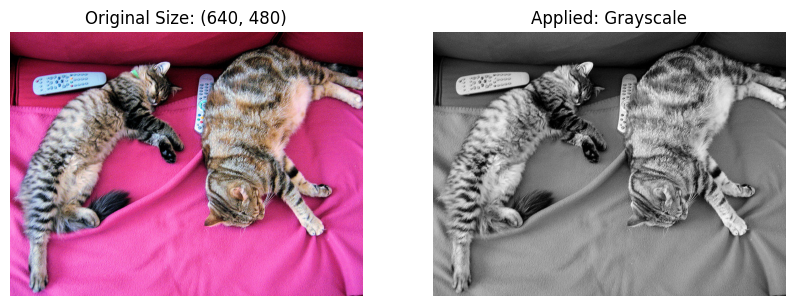

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import random

# Load a REAL image from the web
url = "http://images.cocodataset.org/val2017/000000039769.jpg" # Standard CV demo image
response = requests.get(url)
original_image = Image.open(BytesIO(response.content))

transform_options = {
    "Horizontal Flip": transforms.RandomHorizontalFlip(p=1.0),
    "Vertical Flip": transforms.RandomVerticalFlip(p=1.0),
    "Rotation (45°)": transforms.RandomRotation(degrees=(45, 45)),
    "Color Jitter (High Contrast)": transforms.ColorJitter(brightness=0, contrast=2.0, saturation=0, hue=0),
    "Gaussian Blur": transforms.GaussianBlur(kernel_size=9, sigma=(5.0, 5.0)),
    "Grayscale": transforms.Grayscale(num_output_channels=3),
    "Center Crop": transforms.CenterCrop(200),
}

chosen_name = random.choice(list(transform_options.keys()))
chosen_transform = transform_options[chosen_name]

transformed_image = chosen_transform(original_image)

plt.figure(figsize=(10, 5))

# Plot Original
plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title(f"Original Size: {original_image.size}")
plt.axis("off")

# Plot Transformed
plt.subplot(1, 2, 2)
plt.imshow(transformed_image)
plt.title(f"Applied: {chosen_name}")
plt.axis("off")

plt.show()

# 5. Training Optimization Strategies

Here are two crucial strategies to improve training efficiency and model performance:

- Learning Rate Scheduling
A static learning rate is often inefficient. We want a high learning rate initially to learn fast, and a small learning rate later to fine-tune convergence. PyTorch provides **Schedulers** (like `StepLR` or `CosineAnnealingLR`) to automate this decay process during training.

- Early Stopping
Training for too many epochs often leads to overfitting (where the model memorizes the training data but fails on new data). **Early Stopping** monitors the validation loss: if the loss stops improving for a set number of epochs (patience), the training loop is terminated automatically to save the best model.